In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)

data = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [2]:
print(data.shape)
data.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
data['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Initial Data Inspection 
- The classes are imbalanced with only around 16% class labels being 'Yes'.
- This creates class imbalance as such a model, when trained would only predict a 'No'; that too having 84% accuracy; but the whole concept of the model    would be useless.
- We thus can use evaluation matrices like ROC-AUC and F1 instead of accuracy.
- We can use SMOTE during the preprocessing phase to synthetically balance the classes. 

In [5]:
data.describe(include='all')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


### Observations

- Age range (18-60) is clean with no outliers.
- EmployeeCount, Over18 and StandardHours have zero variance altogether, these columns add no value to the model, thus, can be dropped.
- EmployeeNumber is an arbitrary ID which adds no value to the model so it can be dropped.
- PerformanceRating has a very low variance as nearly everyone is rated either a 3 or 4. Worth flagging for furthur inspection.
- MonthlyIncome is heavily right-skewed having mean of 6,502 but median (50%) of only 4,919. That gap tells you high earners are pulling the mean up. It is normal for income data but important for modeling.
- TotalWorkingYears max is 40 but YearsAtCompany max is also 40. Some employees have spent their entire career at one company. Worth a closer look.
- YearsSinceLastPromotion notes having 75% of employees at 3 years or less, but max is 15. That's a long tail — some employees haven't been promoted in over a decade. Could be a strong attrition signal. 

In [6]:
data = data.drop(columns=['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18'])
data.shape

(1470, 31)

## EDA
### 1. Target Distribution

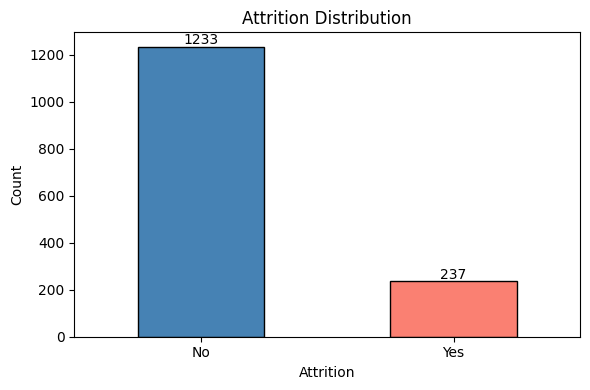

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

data['Attrition'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')

ax.set_title('Attrition Distribution')
ax.set_xlabel('Attrition')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 10), ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/01_attrition_distribution.png', dpi=150)
plt.show()

### 2. Attrition by Overtime

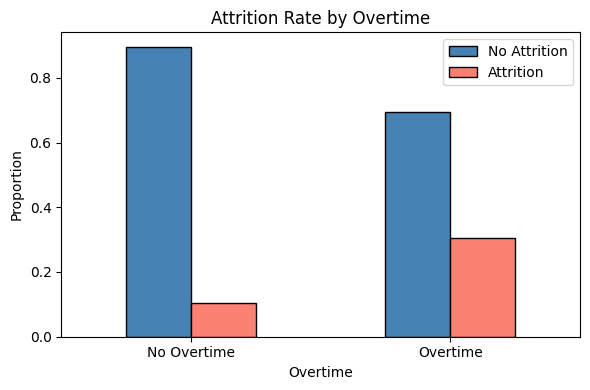

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

overtime_attrition = data.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()
overtime_attrition.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='black')

ax.set_title('Attrition Rate by Overtime')
ax.set_xlabel('Overtime')
ax.set_ylabel('Proportion')
ax.set_xticklabels(['No Overtime', 'Overtime'], rotation=0)
ax.legend(['No Attrition', 'Attrition'])

plt.tight_layout()
plt.savefig('../outputs/figures/02_attrition_by_overtime.png', dpi=150)
plt.show()

- Employees working overtime are 3x more likely to leave than employees who don't do overtimes.

### 3. Monthly Income v/s Attrition

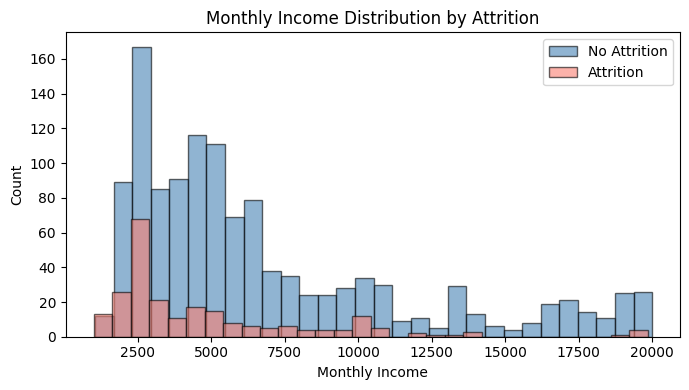

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    data[data['Attrition']=='No']['MonthlyIncome'],
    bins=30,
    alpha=0.6,
    color='steelblue',
    edgecolor='black',
    label='No Attrition'
)

ax.hist(
    data[data['Attrition']=='Yes']['MonthlyIncome'],
    bins=30,
    alpha=0.6,
    color='salmon',
    edgecolor='black',
    label='Attrition'
)

ax.set_title('Monthly Income Distribution by Attrition')
ax.set_xlabel('Monthly Income')
ax.set_ylabel('Count')
ax.legend(['No Attrition', 'Attrition'])

plt.tight_layout()
plt.savefig('../outputs/figures/03_income_vs_attrition.png', dpi=150)
plt.show()

- Lower paid employees are much more likely to leave.

### 4. Age v/s Attrition

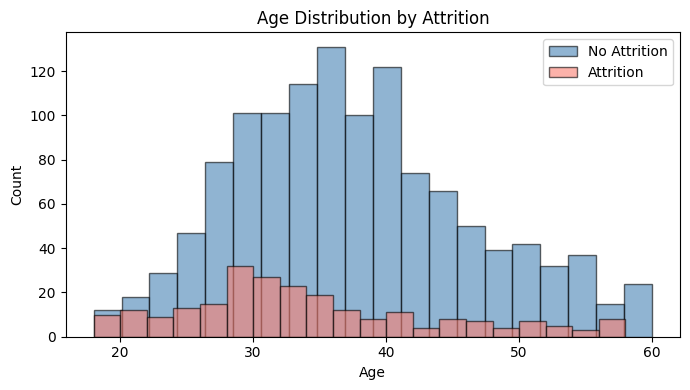

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

data[data['Attrition'] == 'No']['Age'].plot(kind='hist', ax=ax, alpha=0.6, bins=20, color='steelblue', edgecolor='black', label='No Attrition')
data[data['Attrition'] == 'Yes']['Age'].plot(kind='hist', ax=ax, alpha=0.6, bins=20, color='salmon', edgecolor='black', label='Attrition')

ax.set_title('Age Distribution by Attrition')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/04_age_vs_attrition.png', dpi=150)
plt.show()

- People in their late 20s to early 30s are more likely to leave than other age groups.

### 5. Attrition by Department and Job Role

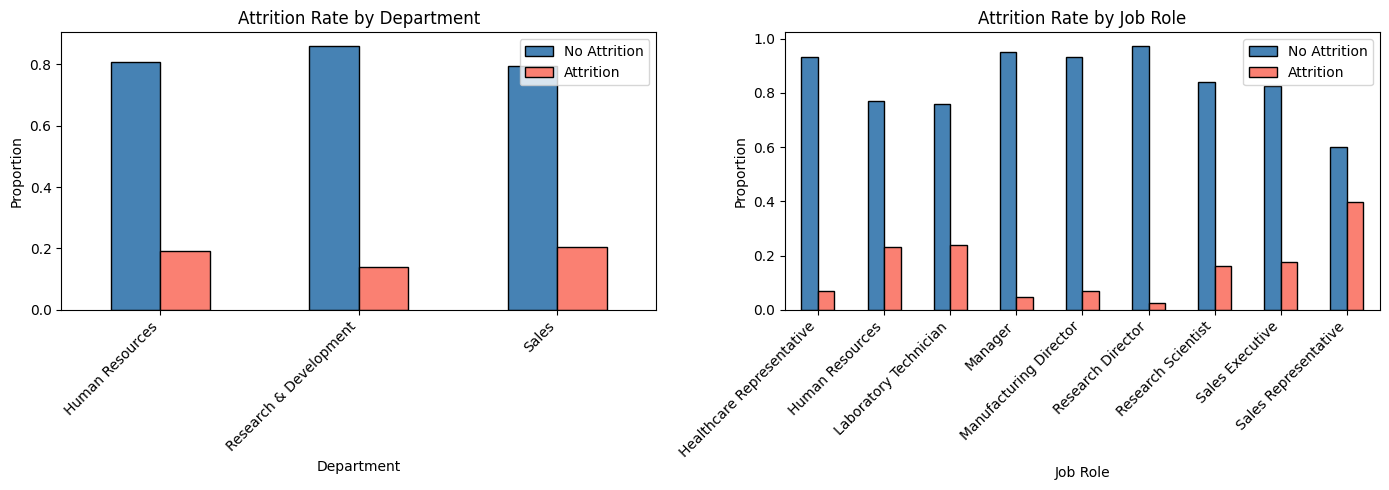

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Department
dept_attrition = data.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
dept_attrition.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Attrition Rate by Department')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].legend(['No Attrition', 'Attrition'])

# Job Role
role_attrition = data.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
role_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role')
axes[1].set_xlabel('Job Role')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(['No Attrition', 'Attrition'])

plt.tight_layout()
plt.savefig('../outputs/figures/05_attrition_by_dept_and_role.png', dpi=150)
plt.show()

- Department alone isn't a strong predictor of attrition but is surely correlated with job roles; a feature that does tell a story.
- Job Role Attrition Patterns I noticed:
- Managers and Research Directors are senior, well compensated, and have authority, thus, low motivation to leave
- Sales Representatives face pressure, and often lower salary, thus, classic high-attrition role
- HR and Lab Technicians are typically junior roles with limited growth visibility and modest pay, thus, more likely to leave

This connects back to the income plot, i.e., the roles with highest attrition are almost certainly the lower paid ones. The features in this dataset aren't independent, they tell a consistent story together.

### 6. Attrition by Marital Status and Business Travel

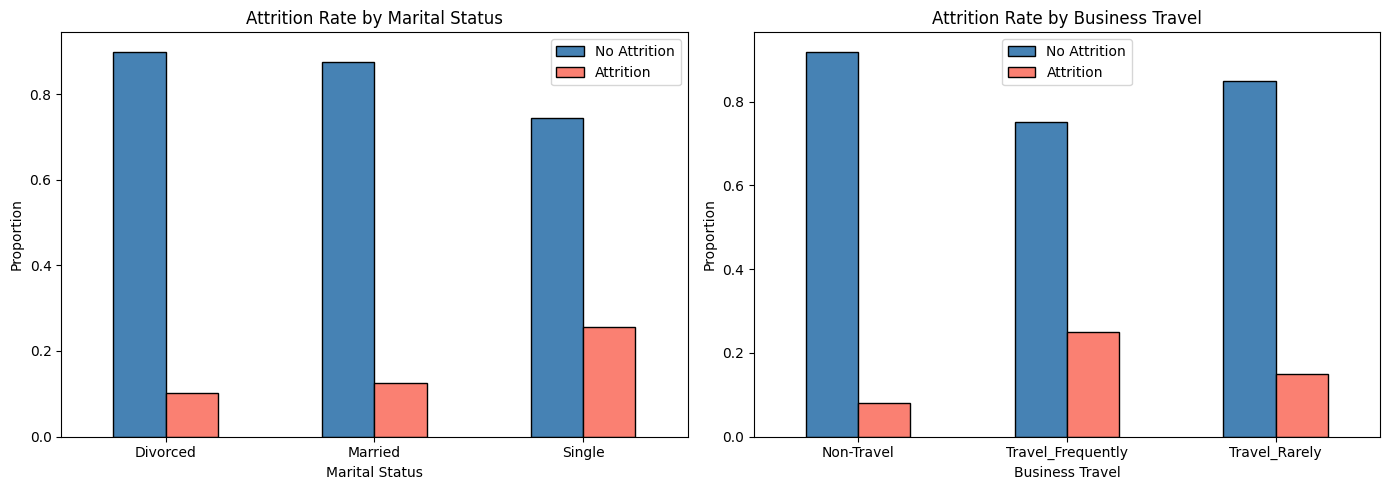

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Marital Status
marital_attrition = data.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True).unstack()
marital_attrition.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Attrition Rate by Marital Status')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Proportion')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(['No Attrition', 'Attrition'])

# Business Travel
travel_attrition = data.groupby('BusinessTravel')['Attrition'].value_counts(normalize=True).unstack()
travel_attrition.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Attrition Rate by Business Travel')
axes[1].set_xlabel('Business Travel')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No Attrition', 'Attrition'])

plt.tight_layout()
plt.savefig('../outputs/figures/06_attrition_by_marital_and_travel.png', dpi=150)
plt.show()

- Single employees are almost 3x more likely to leave than others. Some reasons can be - no family anchors, geographic flexibility, less financial pressure. They can take risks much more easily than married employees with mortgages and dependents.
- Frequent travelers are around 2x more likely to leave than others because constant travel means burnout and poor work-life balance. This connects to the overtime finding (both are essentially measuring the same underlying theme: work demands bleeding into personal life drive attrition).

### 7. Attrition by Years At Company

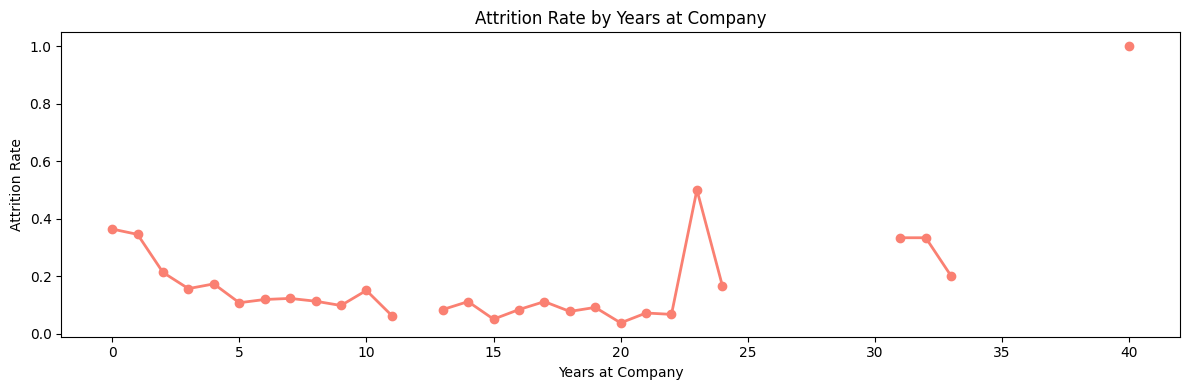

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))

tenure_attrition = data.groupby('YearsAtCompany')['Attrition'].value_counts(normalize=True).unstack()
tenure_attrition['Yes'].plot(kind='line', ax=ax, color='salmon', marker='o', linewidth=2)

ax.set_title('Attrition Rate by Years at Company')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Attrition Rate')

plt.tight_layout()
plt.savefig('../outputs/figures/07_attrition_by_tenure.png', dpi=150)
plt.show()

- The first 5 years of an employee at the company are the highest risk period, that's where retention efforts should be focused.
- After 5 years, the employee has invested enough in the company that the attrition risk is low

### Correlation Heatmap

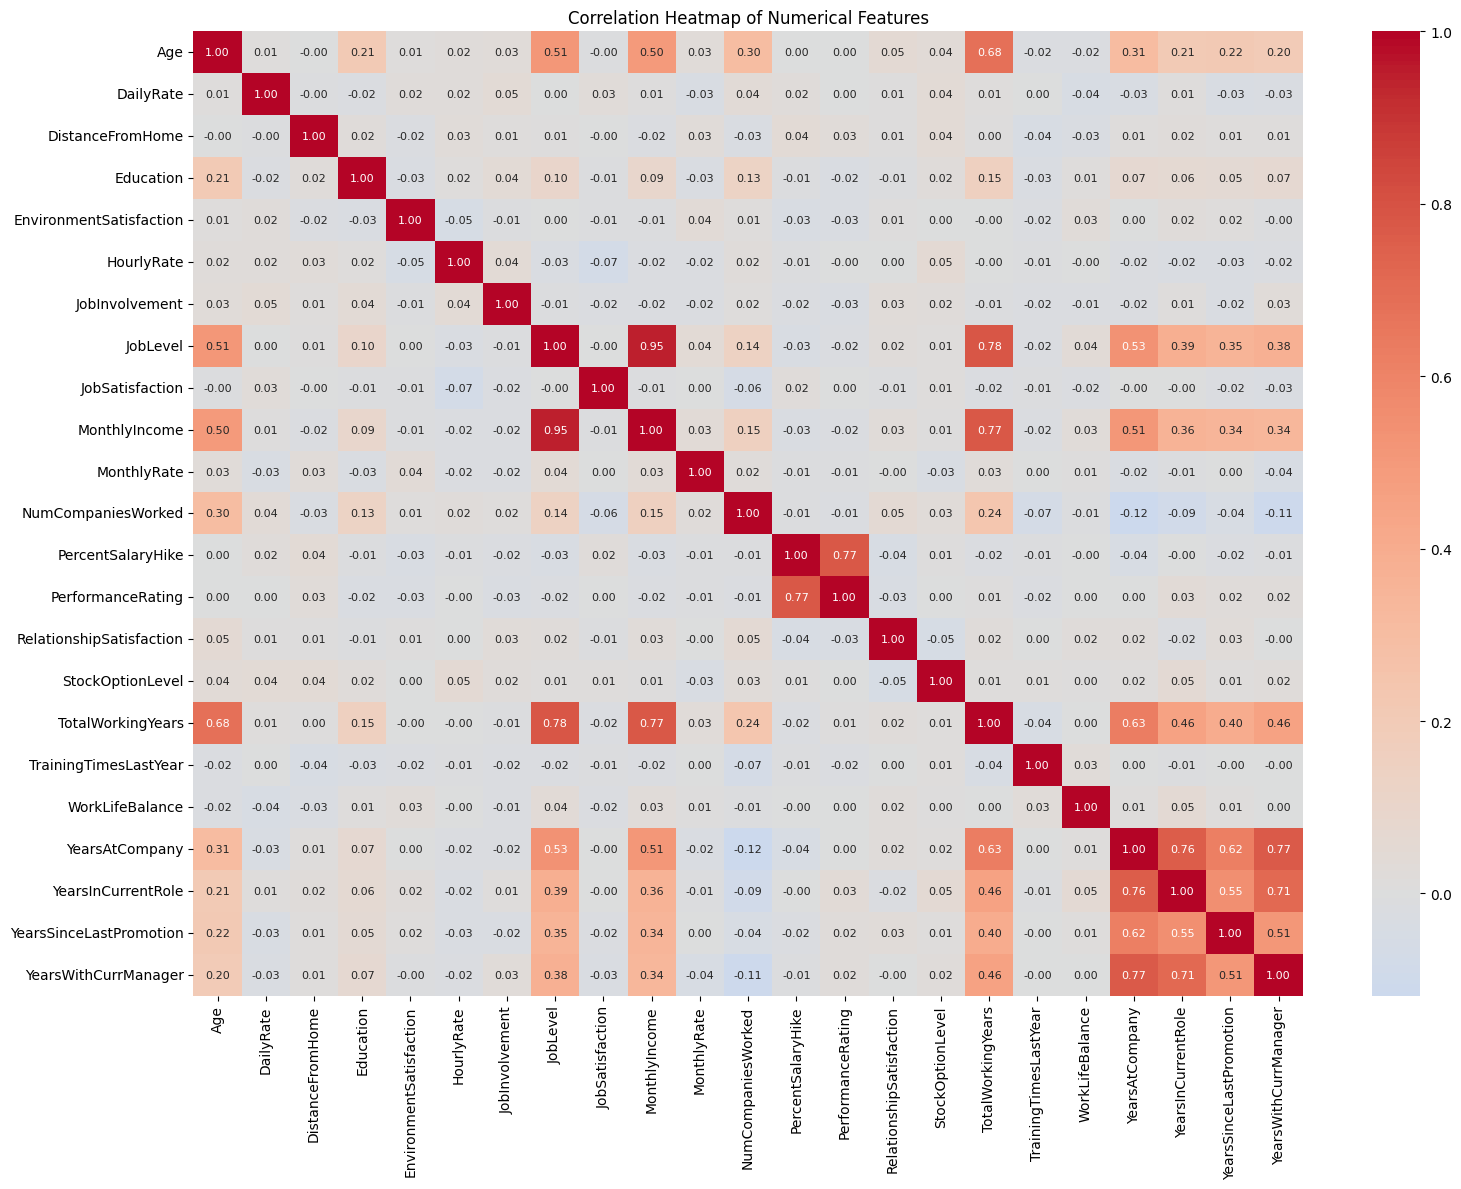

In [14]:
fig, ax = plt.subplots(figsize=(16, 12))

corr_matrix = data.select_dtypes(include='number').corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={'size': 8})

ax.set_title('Correlation Heatmap of Numerical Features')

plt.tight_layout()
plt.savefig('../outputs/figures/08_correlation_heatmap.png', dpi=150)
plt.show()

- SENIORITY: JobLevel, MonthlyIncome, TotalWorkingYears are all highly correlated with each other (0.95, 0.78, 0.77). The more years you've worked, the higher your job level, and the higher your salary.
- TENURE: YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager are all correlated (0.76, 0.77, 0.71). If you've been at the company long, you've likely been in your role long and had the same manager long.
- PerformanceRating and PercentSalaryHike at 0.77 — raises are directly tied to performance ratings, so this is expected.

## EDA Summary

1. Data overview (describe(include='all'))
- Age 18-60, looks clean.
- Zero-variance columns: EmployeeCount, Over18, StandardHours -> dropped.
- EmployeeNumber is ID -> dropped.
- PerformanceRating low variance (mostly 3/4).
- MonthlyIncome heavy right skew (mean > median).
- YearsSinceLastPromotion long tail (max 15, 75% <=3).
- Noted TotalWorkingYears and YearsAtCompany both max 40.

2. Target distribution plot
- Bar chart of attrition class counts.

3. Attrition by Overtime
- Group by OverTime, Attrition (proportion).
- Insight: overtime workers ~3x likelihood of leaving.

4. Monthly Income vs Attrition
- Insight: lower income drives higher attrition.

5. Age vs Attrition
- Insight: late 20s to early 30s higher attrition.

6. Attrition by Department and JobRole
- Insights:
- Role matters more than dept.
- High attrition in Sales, HR, Lab Technician.
- Lower attrition in Manager, Research Director.
- Relates to income/seniority themes.

7. Attrition by Marital Status + Business Travel
- Insights:
- Single employees ~3x attrition risk.
- Frequent travel ~2x attrition risk (work-life stress + overtime similarity).

8. Attrition by YearsAtCompany
- Insights:
- First 5 years = highest risk.
- After 5 years, risk drops significantly.

9. Correlation heatmap (numerical features)
- corr() on numeric columns.
- Observations:
- JobLevel, MonthlyIncome, TotalWorkingYears strong corr.
- YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager strong corr.
- PerformanceRating with PercentSalaryHike ~0.77.